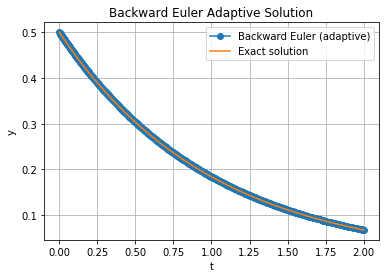

In [9]:
import numpy as np
import matplotlib.pyplot as plt

def f(t, y):
    return -y

# derivative w.r.t y for Newton method
def df_dy(t, y):
    return -1


def backward_euler_step(f, df_dy, y, t, h, tol=1e-6, max_iter=50):
    y_next = y  # initial guess

    for _ in range(max_iter):
        g = y_next - y - h * f(t + h, y_next)
        gp = 1 - h * df_dy(t + h, y_next)

        if abs(gp) < 1e-14:
            raise RuntimeError("Derivative too small in Newton step")

        y_new = y_next - g / gp

        if abs(y_new - y_next) < tol:
            return y_new

        y_next = y_new

    return y_next


def backward_euler_adaptive(f, df_dy, y0, t0, tf, h_init, tol=1e-6):
    t_values = [t0]
    y_values = [y0]

    t = t0
    y = y0
    h = h_init

    while t < tf:
        if t + h > tf:
            h = tf - t

        # full step
        y_full = backward_euler_step(f, df_dy, y, t, h, tol)

        # two half steps
        h2 = h / 2
        y_half = backward_euler_step(f, df_dy, y, t, h2, tol)
        y_half = backward_euler_step(f, df_dy, y_half, t + h2, h2, tol)

        error = abs(y_full - y_half)

        # adaptive control
        if error > tol:
            h *= 0.5
            continue

        # accept step
        t += h
        y = y_half

        t_values.append(t)
        y_values.append(y)

        if error < tol / 4:
            h *= 2

    return np.array(t_values), np.array(y_values)


# problem setup
y0 = 0.5
t0 = 0.0
tf = 2.0
h_init = 0.1

t_vals, y_vals = backward_euler_adaptive(f, df_dy, y0, t0, tf, h_init)

def y_exact(t):
    return 0.5 * np.exp(-t)

y_exact_vals = y_exact(t_vals)

plt.plot(t_vals, y_vals, 'o-', label="Backward Euler (adaptive)")
plt.plot(t_vals, y_exact_vals, '-', label="Exact solution")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Backward Euler Adaptive Solution")
plt.grid(True)
plt.legend()
plt.show()